
### Importing the libralies and the data

In [767]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [768]:
train = pd.read_csv('train.csv')
test =  pd.read_csv('test.csv')

### EDA

In [769]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [770]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [771]:
train.select_dtypes(include='float64').isnull().sum()[train.isnull().sum()>0].sort_values(ascending=False)

ShoppingMall    208
VRDeck          188
FoodCourt       183
Spa             183
RoomService     181
Age             179
dtype: int64

In [772]:
num_cols = ['ShoppingMall','VRDeck','Spa','FoodCourt','RoomService','Age']

In [773]:
def plotDist(num_cols):
    s= len(num_cols)
    plt.figure(figsize=(20,10))
    for i,col in enumerate(num_cols,1):
        plt.subplot(2,3,i)
        plt.hist(train[col])
        plt.title(col)
    
    plt.tight_layout()
    plt.show()

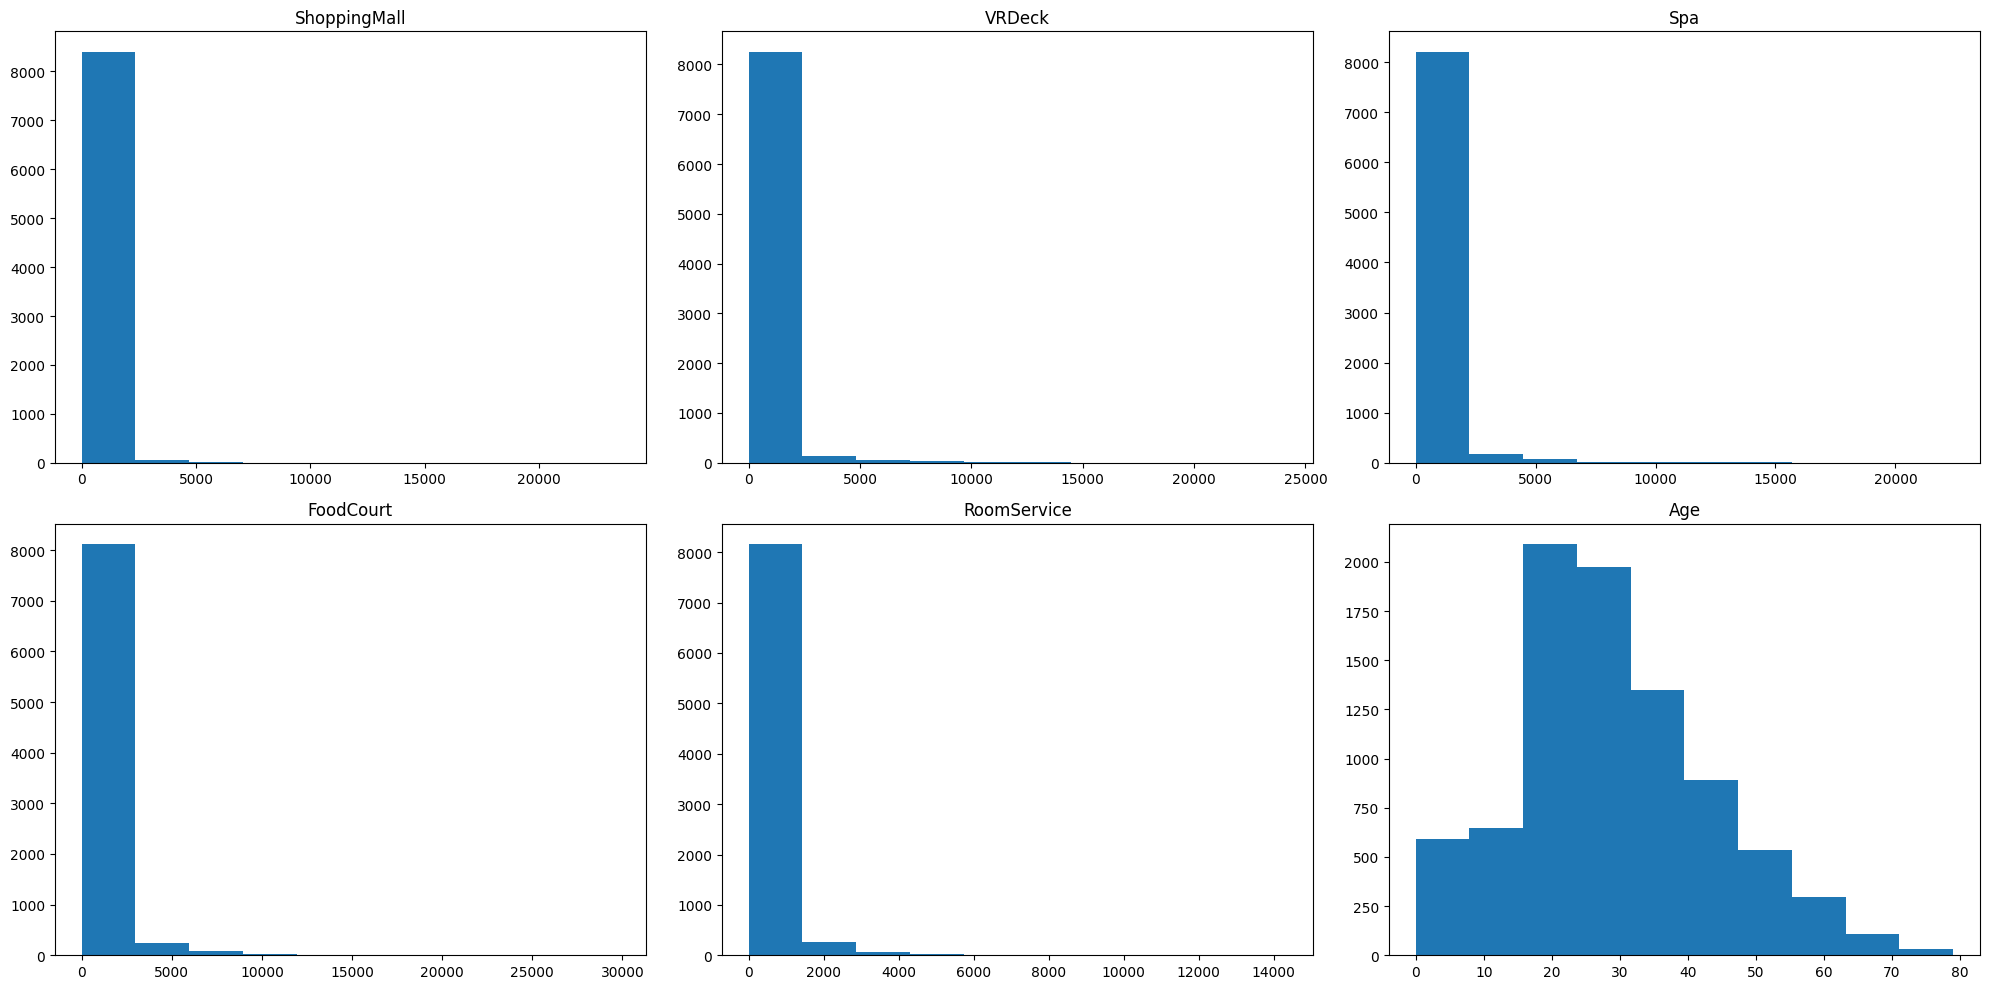

In [774]:
plotDist(num_cols)

In [775]:
num_cols

['ShoppingMall', 'VRDeck', 'Spa', 'FoodCourt', 'RoomService', 'Age']

In [776]:
for col in num_cols:
    train[col]=train[col].fillna(train[col].median())


In [777]:
train.select_dtypes(include='float64').isnull().sum().sort_values(ascending=False)

Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [778]:
def plotDisttest(num_cols):
    s= len(num_cols)
    plt.figure(figsize=(20,10))
    for i,col in enumerate(num_cols,1):
        plt.subplot(2,3,i)
        plt.hist(train[col])
        plt.title(col)
    
    plt.tight_layout()
    plt.show()

In [779]:
test.select_dtypes(include='float64').isnull().sum()[test.isnull().sum()>0].sort_values(ascending=False)

FoodCourt       106
Spa             101
ShoppingMall     98
Age              91
RoomService      82
VRDeck           80
dtype: int64

In [780]:
num_cols

['ShoppingMall', 'VRDeck', 'Spa', 'FoodCourt', 'RoomService', 'Age']

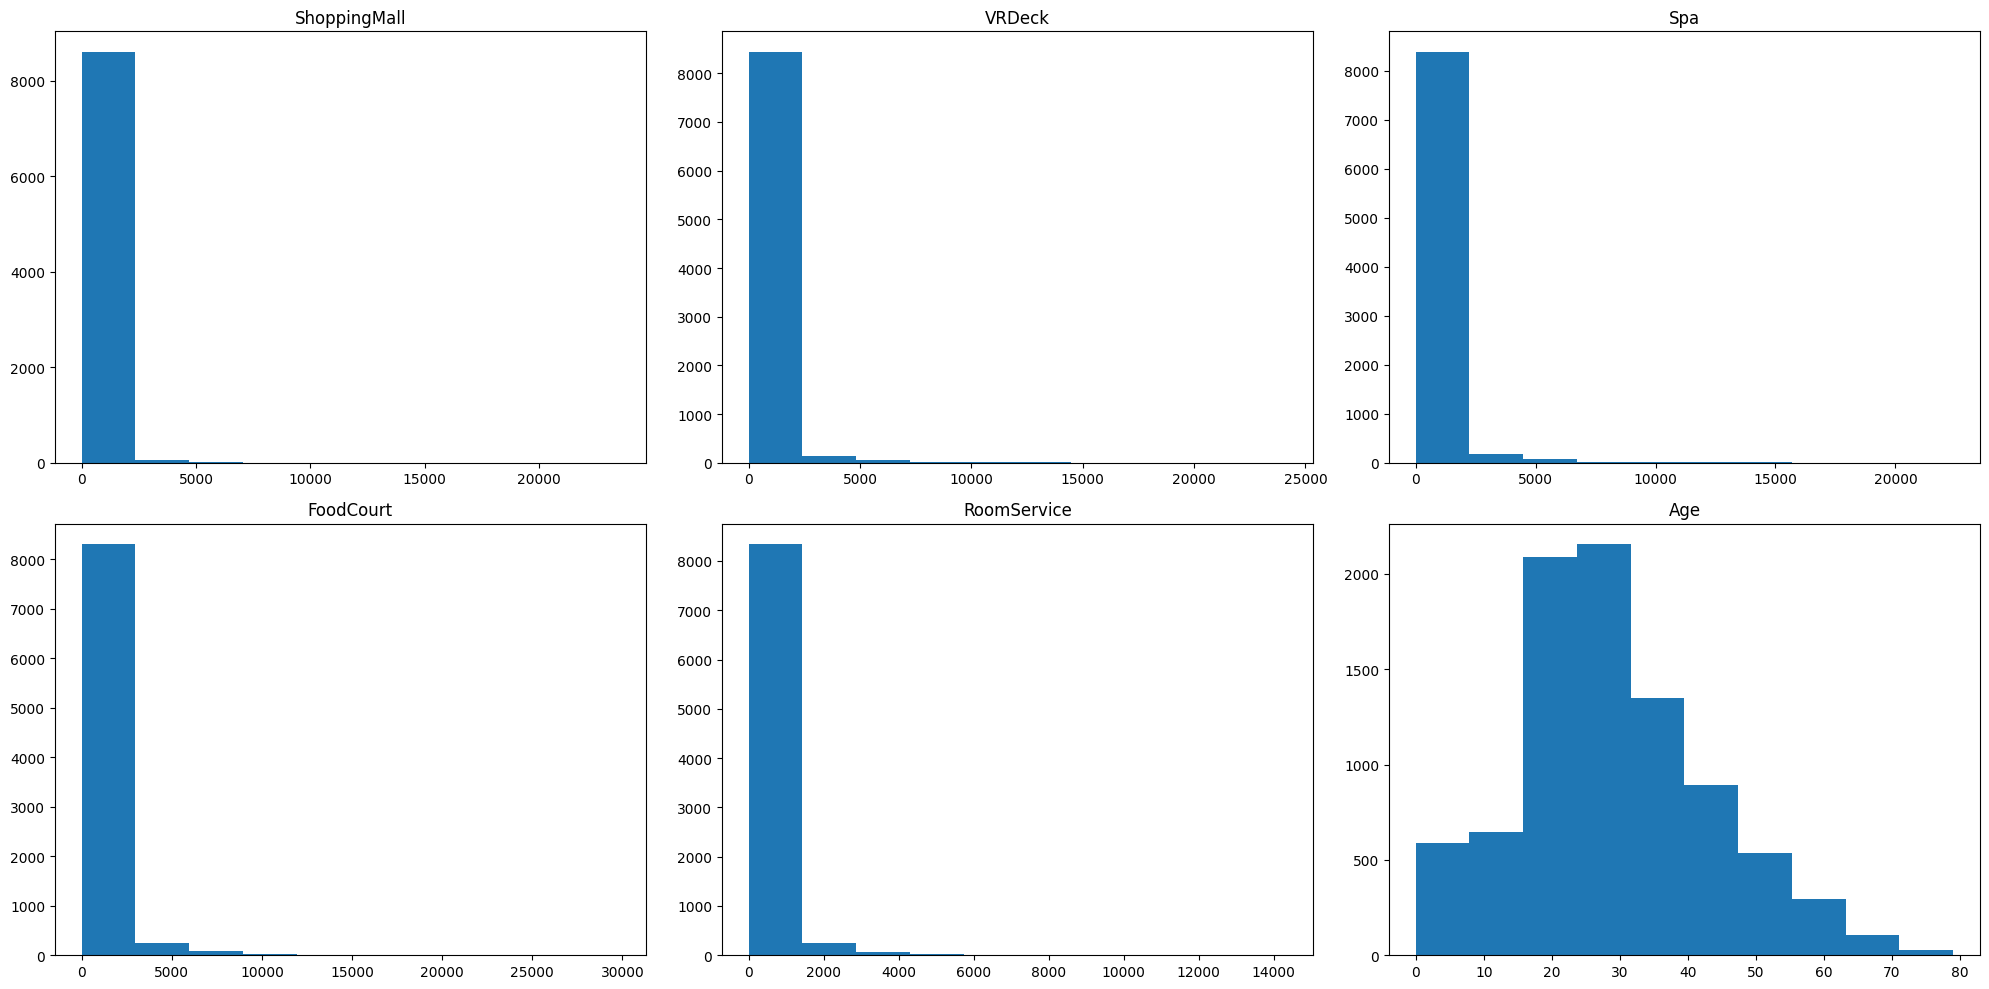

In [781]:
plotDisttest(num_cols)

In [782]:
for col in num_cols:
    test[col] = test[col].fillna(test[col].median())

In [783]:
test.select_dtypes(include='float64').isnull().sum().sort_values(ascending=False)

Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [784]:
train.select_dtypes(include='object').isnull().sum()[train.isnull().sum()>0].sort_values(ascending=False)

CryoSleep      217
VIP            203
HomePlanet     201
Name           200
Cabin          199
Destination    182
dtype: int64

In [785]:
test.select_dtypes(include='object').isnull().sum()[test.isnull().sum()>0].sort_values(ascending=False)

Cabin          100
Name            94
VIP             93
CryoSleep       93
Destination     92
HomePlanet      87
dtype: int64

In [786]:
obj_cols = ['Destination','HomePlanet']

In [787]:
cat_cols =['VIP','CryoSleep','HomePlanet','Destination']
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

C:\Users\asus\AppData\Local\Temp\ipykernel_6532\3325233509.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[col] = train[col].fillna(train[col].mode()[0])
C:\Users\asus\AppData\Local\Temp\ipykernel_6532\3325233509.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[col] = test[col].fillna(test[col].mode()[0])


In [788]:
train.drop(columns='Name', inplace=True)
test.drop(columns='Name', inplace=True)

In [789]:
train.select_dtypes(include='object').isnull().sum()[train.isnull().sum()>0].sort_values(ascending=False)

Cabin    199
dtype: int64

In [790]:
test.select_dtypes(include='object').isnull().sum()[test.isnull().sum()>0].sort_values(ascending=False)

Cabin    100
dtype: int64

In [791]:
train[['Deck','CabinNum','Side']] = train['Cabin'].str.split('/',expand=True)

In [792]:
test[['Deck','CabinNum','Side']] = test['Cabin'].str.split('/',expand=True)

In [793]:
train.drop(columns='Cabin', inplace=True)
test.drop(columns='Cabin', inplace=True)

In [794]:
train['CabinNum'] = train['CabinNum'].astype(float)
train['Deck'] = train['Deck'].fillna(train['Deck'].mode()[0])
train['Side'] = train['Side'].fillna(train['Side'].mode()[0])

train['CabinNum'] = train['CabinNum'].fillna(
    train['CabinNum'].median()
)

In [795]:
test['CabinNum'] = test['CabinNum'].astype(float)
test['Deck'] = test['Deck'].fillna(test['Deck'].mode()[0])
test['Side'] = test['Side'].fillna(test['Side'].mode()[0])

test['CabinNum'] = test['CabinNum'].fillna(
    test['CabinNum'].median()
)

In [796]:
test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Deck            0
CabinNum        0
Side            0
dtype: int64

In [797]:
X = train.drop('Transported', axis=1)
y = train['Transported']

In [798]:
result = pd.DataFrame()
result['PassengerId'] = test['PassengerId']

In [799]:
X.drop(columns='PassengerId', inplace=True)
test.drop(columns='PassengerId', inplace=True)

In [800]:
X

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,B,0.0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,F,0.0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,A,0.0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,A,0.0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,F,1.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,A,98.0,P
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,G,1499.0,S
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,G,1500.0,S
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,E,608.0,S


In [801]:
test

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side
0,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,G,3.0,S
1,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,F,4.0,S
2,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,C,0.0,S
3,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,C,1.0,S
4,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,F,5.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,Earth,True,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,G,1496.0,S
4273,Earth,False,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,F,442.0,S
4274,Mars,True,55 Cancri e,26.0,False,0.0,0.0,0.0,0.0,0.0,D,296.0,P
4275,Europa,False,TRAPPIST-1e,26.0,False,0.0,2680.0,0.0,0.0,523.0,D,297.0,P


ENCODING

In [802]:
x= pd.get_dummies(X,drop_first=True)

In [803]:
test = pd.get_dummies(test,drop_first=True)

In [804]:
bool_cols = x.select_dtypes(include='bool').columns

In [805]:
bool_cols

Index(['CryoSleep', 'VIP', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_B',
       'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_S'],
      dtype='object')

In [806]:
x[bool_cols] = x[bool_cols].astype(int)
test[bool_cols] = test[bool_cols].astype(int)

### Data ready for training and testing:


Importing neccesary models 
    -training on logistic regression and Random forest without tuning
    

In [807]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [808]:
x

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CabinNum,HomePlanet_Europa,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1,...,0,1,1,0,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,0.0,0,...,0,1,0,0,0,0,1,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0.0,1,...,0,1,0,0,0,0,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0.0,1,...,0,1,0,0,0,0,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1.0,0,...,0,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,98.0,1,...,0,0,0,0,0,0,0,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,1499.0,0,...,1,0,0,0,0,0,0,1,0,1
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1500.0,0,...,0,1,0,0,0,0,0,1,0,1
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,608.0,1,...,0,0,0,0,0,1,0,0,0,1


In [809]:
y = y.astype(int)


In [810]:
y

0       0
1       1
2       0
3       0
4       1
       ..
8688    0
8689    0
8690    1
8691    0
8692    1
Name: Transported, Length: 8693, dtype: int64

<Axes: xlabel='Transported', ylabel='count'>

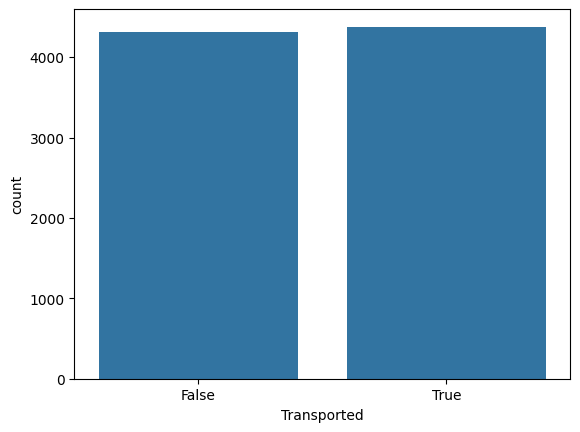

In [811]:
sns.countplot(train,x = 'Transported')

In [812]:
x['TotalSpend'] = (
    x['RoomService'] +
    x['FoodCourt'] +
    x['ShoppingMall'] +
    x['Spa'] +
    x['VRDeck']
)
test['TotalSpend'] = (
    test['RoomService'] +
    test['FoodCourt'] +
    test['ShoppingMall'] +
    test['Spa'] +
    test['VRDeck']
)

In [813]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.25,random_state=42)

In [814]:
lr_model = LogisticRegression()
rfc_model = RandomForestClassifier()

In [815]:
lr_model.fit(x_train,y_train)

C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [816]:
rfc_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [817]:
lr_predict = lr_model.predict(x_test)
rfc_predict = rfc_model.predict(x_test)

IMPORTING evaluation metrics

In [818]:
from sklearn.metrics import accuracy_score

In [819]:
print(accuracy_score(y_test,lr_predict))
print(accuracy_score(y_test,rfc_predict))

0.7833486660533578
0.7948482060717571


Optizing the Random Forest Classifer with random search cv


In [820]:
from sklearn.model_selection import RandomizedSearchCV

In [821]:
rfc_optimized = RandomForestClassifier()

In [822]:
param_dist = {
    'n_estimators': [100,200,300,500],
    'max_depth': [None,5,10,20,30],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2'],
    'criterion': ['gini','entropy'],
    'bootstrap': [True, False]
}

In [823]:
randomsearch = RandomizedSearchCV(
    estimator=rfc_optimized,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    verbose=2,
    n_jobs=-1
    
)

In [824]:
randomsearch.fit(x_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], ...}"
,n_iter,25
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [825]:
opt_predict = randomsearch.predict(x_test)

In [826]:
accuracy_score(y_test,opt_predict)

0.7934682612695492

## Using XGBOOST 

In [827]:
from xgboost import XGBClassifier

In [828]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [829]:
xgb_model.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [830]:
xgb_predict = xgb_model.predict(x_test)

In [831]:
accuracy_score(y_test,xgb_predict)

0.7999080036798528

In [832]:
param_dist = {
    'n_estimators': [100,200,300,500],
    'learning_rate': [0.01,0.03,0.05,0.1],
    'max_depth': [3,4,5,6,8],
    'subsample': [0.7,0.8,1.0],
    'colsample_bytree': [0.7,0.8,1.0]
}

In [833]:
xgb_randomsearch = RandomizedSearchCV(
    estimator=XGBClassifier(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [834]:
xgb_randomsearch.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [835]:
xgb_rs_predict=xgb_randomsearch.predict(x_test)

In [836]:
accuracy_score(y_test,xgb_rs_predict)

0.8017479300827967

random search XGB outperforms best 

## Making submissions csv by predicting on test.csv

In [837]:
final_pred = xgb_randomsearch.predict(test)

In [839]:
result['Transported'] = final_pred

In [841]:
result['Transported'] = result['Transported'].astype(bool)

In [842]:
result

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [843]:
result.to_csv("space_titanic_submission.csv",index=False)